In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("car.csv")
df

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...,...
4335,Hyundai i20 Magna 1.4 CRDi (Diesel),2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner
4336,Hyundai i20 Magna 1.4 CRDi,2014,409999.0,80000.0,Diesel,Individual,Manual,Second Owner
4337,Maruti 800 AC BSIII,2009,110000.0,83000.0,Petrol,Individual,Manual,Second Owner
4338,Hyundai Creta 1.6 CRDi SX Option,2016,865000.0,90000.0,Diesel,Individual,Manual,First Owner


In [ ]:
df.describe()


,year,selling_price,km_driven
count,4340.000000,4.339000e+03,4338.000000
mean,2013.090783,5.042205e+05,66243.652374
std,4.215344,5.785829e+05,46636.666295
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.100000e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
df1.describe()

,year,selling_price,km_driven
count,4340.000000,4.339000e+03,4338.000000
mean,2013.090783,5.042205e+05,66243.652374
std,4.215344,5.785829e+05,46636.666295
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.100000e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [ ]:
df1=df.drop(columns=['name'],axis=1)

In [ ]:
df1.describe(include='object')

,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340
unique,5,3,2,5
top,Diesel,Individual,Manual,First Owner
freq,2153,3244,3892,2832


In [ ]:
df1.isna().sum()

,0
year,0
selling_price,1
km_driven,2
fuel,0
seller_type,0
transmission,0
owner,0


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           4340 non-null   int64  
 1   selling_price  4339 non-null   float64
 2   km_driven      4338 non-null   float64
 3   fuel           4340 non-null   object 
 4   seller_type    4340 non-null   object 
 5   transmission   4340 non-null   object 
 6   owner          4340 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 237.5+ KB


In [ ]:
df1['km_driven'] = pd.to_numeric(df1['km_driven'], errors='coerce').fillna(df1['km_driven'].mode()[0])

In [ ]:
df1.isna().sum()

,0
year,0
selling_price,1
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [ ]:
df1=df1.dropna()

In [ ]:
x1=df1['year']
y1=df1['selling_price']

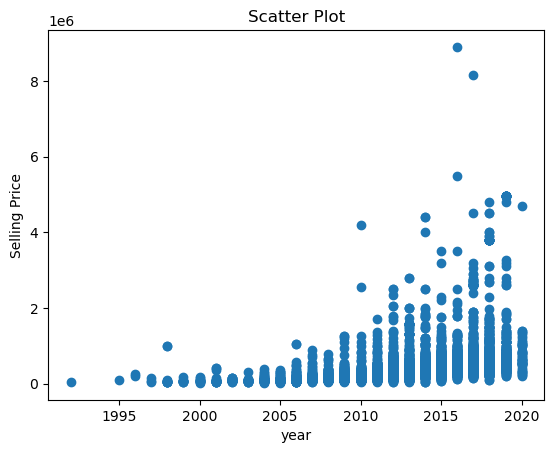

In [ ]:
plt.figure()
plt.scatter(x1,y1)
plt.xlabel("year")
plt.ylabel('Selling Price')
plt.title("Scatter Plot")
plt.show()

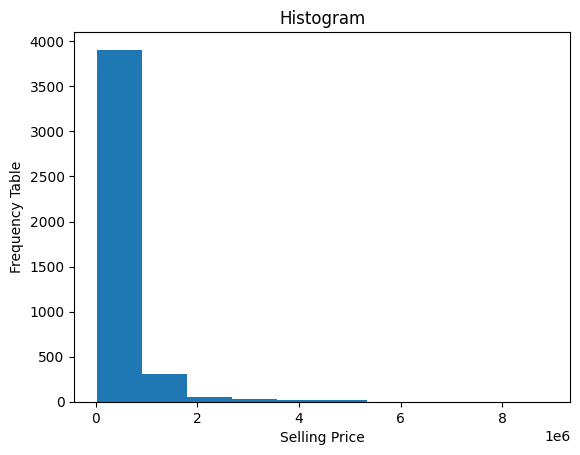

In [ ]:
plt.figure()
plt.hist(df1['selling_price'])
plt.xlabel("Selling Price")
plt.ylabel("Frequency Table")
plt.title("Histogram")
plt.show()

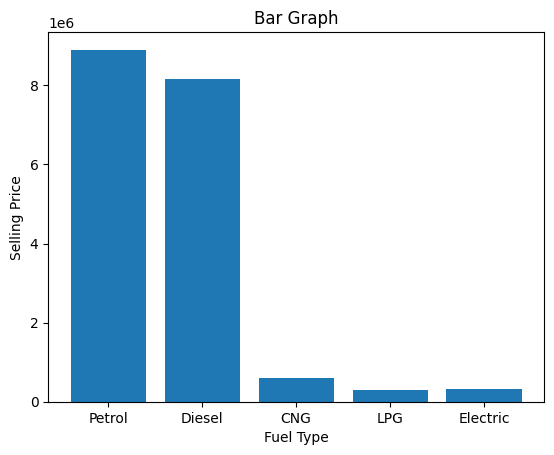

In [ ]:
plt.figure()
plt.bar(df1['fuel'],df1['selling_price'])
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.title("Bar Graph")
plt.show()

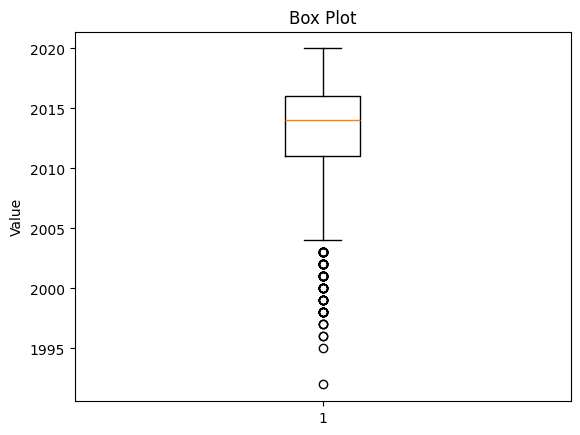

In [ ]:
plt.figure()
plt.boxplot(df1['year'])
plt.ylabel("Value")
plt.title("Box Plot")
plt.show()

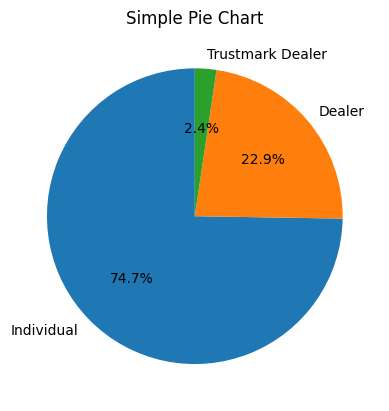

In [ ]:

plt.figure()
plt.pie(df1['seller_type'].value_counts(), labels=df1['seller_type'].unique(),startangle=90,autopct='%1.1f%%')
plt.title('Simple Pie Chart')
plt.show()

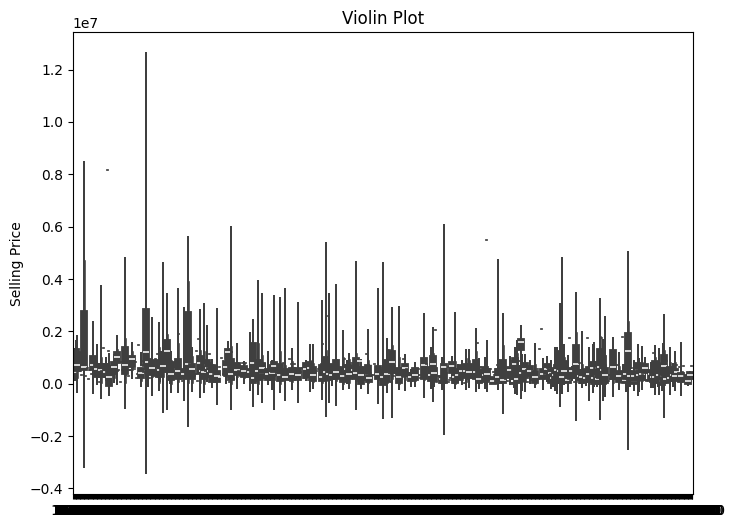

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(x=df["km_driven"], y=df1['selling_price'])

plt.title('Violin Plot')
plt.xlabel("")
plt.ylabel("Selling Price")
plt.show()

In [ ]:
categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
df_encoded = pd.get_dummies(df1, columns=categorical_cols, drop_first=True)
print("DataFrame after one-hot encoding:\n")
df_encoded.head()

DataFrame after one-hot encoding:



,year,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2007,60000.0,70000.0,False,False,False,True,True,False,True,False,False,False,False
1,2007,135000.0,50000.0,False,False,False,True,True,False,True,False,False,False,False
2,2012,600000.0,100000.0,True,False,False,False,True,False,True,False,False,False,False
3,2017,250000.0,46000.0,False,False,False,True,True,False,True,False,False,False,False
4,2014,450000.0,141000.0,True,False,False,False,True,False,True,False,True,False,False


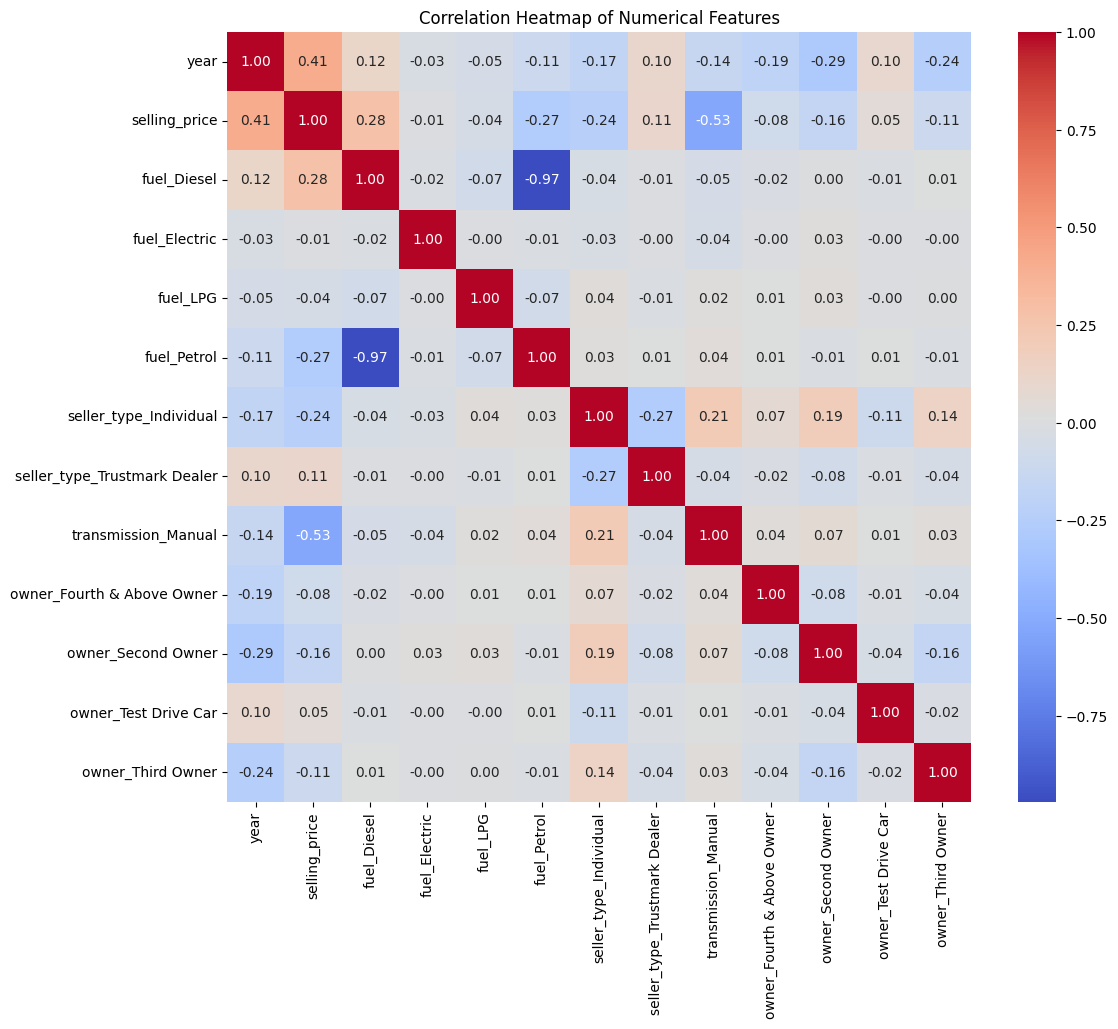

In [ ]:
correlation_matrix = df_encoded.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

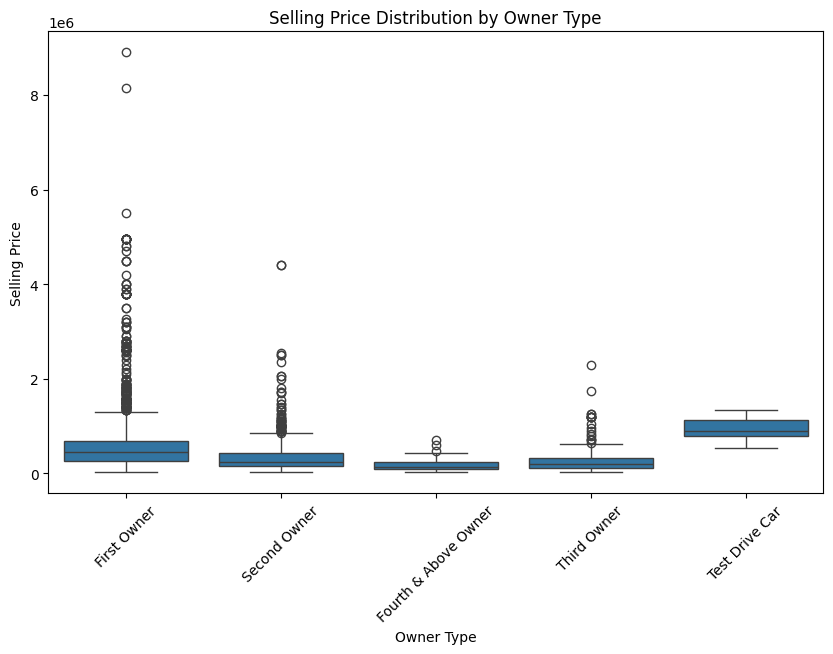

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='owner', y='selling_price', data=df1)
plt.title('Selling Price Distribution by Owner Type')
plt.xlabel('Owner Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=45)
plt.show()

<Figure size 1000x800 with 0 Axes>

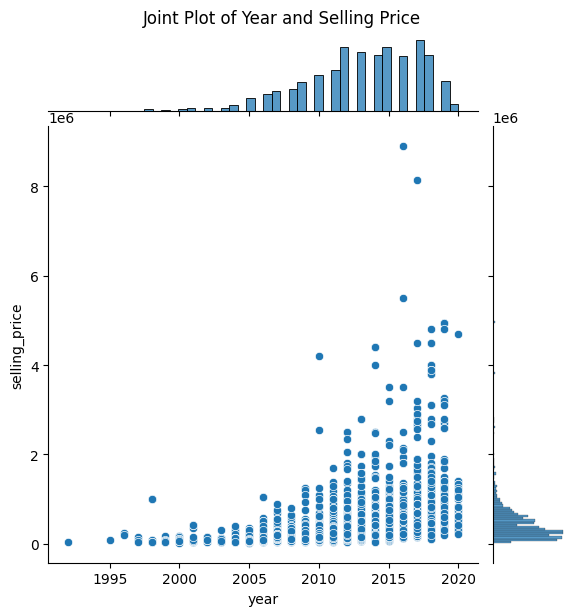

In [ ]:
plt.figure(figsize=(10, 8))
sns.jointplot(x='year', y='selling_price', data=df1, kind='scatter')
plt.suptitle('Joint Plot of Year and Selling Price', y=1.02)
plt.show()

<Figure size 1000x600 with 0 Axes>

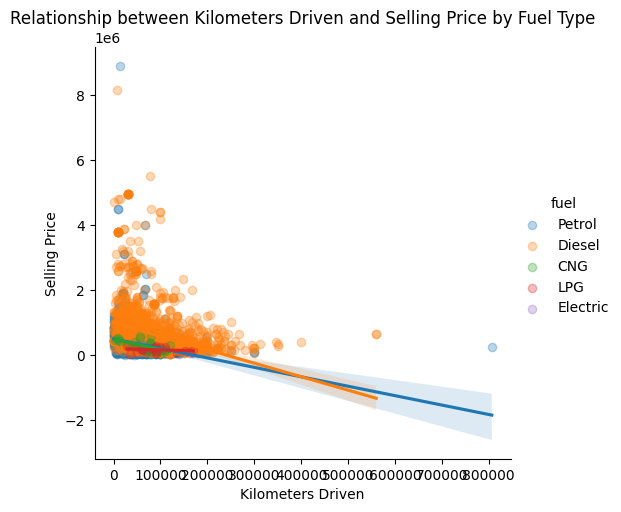

In [ ]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df1, x='km_driven', y='selling_price', hue='fuel', ci=95, scatter_kws={'alpha':0.3})
plt.title('Relationship between Kilometers Driven and Selling Price by Fuel Type')
plt.xlabel('Kilometers Driven')
plt.ylabel('Selling Price')
plt.show()

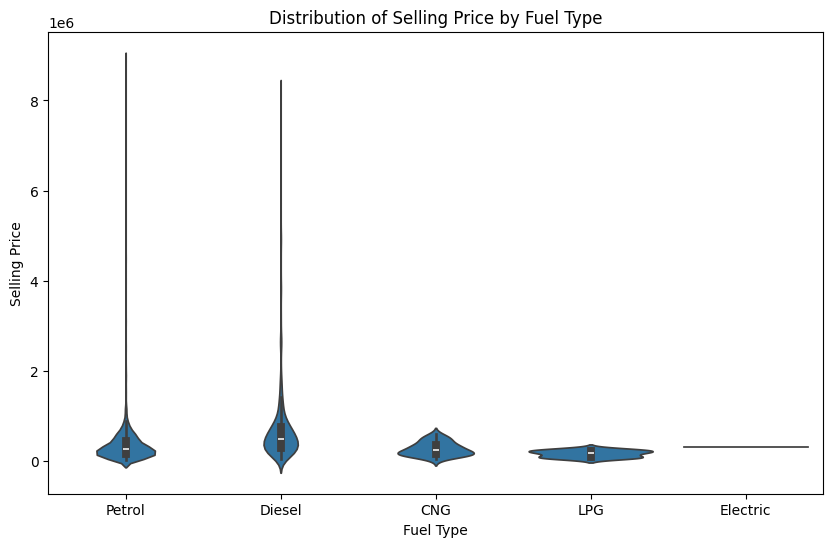

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='fuel', y='selling_price', data=df1)
plt.title('Distribution of Selling Price by Fuel Type')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.show()